# Capítulo 2 — Introduction to Machine Learning

Siguiendo [dmol.pub/ml/introduction.html](https://dmol.pub/ml/introduction.html).

Entorno: kernel `Python (dmol)`. Datos ya descargados en `../data/`.

## 2.1 The Ingredients

Los tres ingredientes de cualquier modelo de ML:

1. **Datos de entrada** — lo que observas de cada ejemplo. En química: una molécula, descrita de algún modo numérico.
2. **El modelo** — una función $\hat{y} = f(\vec{x};\,\vec{w})$ con parámetros ajustables $\vec{w}$.
3. **La función de pérdida (loss)** — un número que mide cuánto se equivoca el modelo. Entrenar = mover $\vec{w}$ para bajar ese número.

Vocabulario que se repite todo el libro:

| Término | Símbolo | Qué es aquí |
|---|---|---|
| *feature* (variable de entrada) | $\vec{x}$ | descriptores moleculares: peso molecular, logP, TPSA... |
| *label* (etiqueta, lo que queremos predecir) | $y$ | la solubilidad medida |
| *parámetros / pesos* | $\vec{w}$ | lo que el entrenamiento ajusta |
| *predicción* | $\hat{y}$ | lo que el modelo dice |

## 2.2 Supervised Learning

**Aprendizaje supervisado**: predecir $y$ a partir de $\vec{x}$ usando un modelo entrenado con ejemplos donde ya conocemos $y$.
"Supervisado" = durante el entrenamiento le enseñamos al algoritmo la respuesta correcta.

**Aprendizaje no supervisado**: buscar estructura en los datos *sin* etiquetas (lo veremos en 2.4 con clustering).

El dataset del capítulo es **AqSolDB**: ~10.000 compuestos con su solubilidad en agua medida.
La solubilidad viene en **log molaridad** — es decir, $\log_{10}$ de la concentración en mol/L de la
disolución saturada. Valores negativos = poco soluble; un $-8$ es prácticamente insoluble y un $0$ es 1 mol/L.

> Se usa el logaritmo porque la solubilidad abarca muchísimos órdenes de magnitud. En escala lineal
> el modelo solo "vería" los compuestos muy solubles; en escala log todos pesan parecido.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

### Cargar los datos

El libro descarga el CSV por URL en cada ejecución; nosotros lo tenemos cacheado en `data/`
(mismo fichero, `curated-solubility-dataset.csv`).

In [2]:
soldata = pd.read_csv("../data/curated-solubility-dataset.csv")
print("filas (compuestos):", soldata.shape[0])
print("columnas:", soldata.shape[1])

filas (compuestos): 9982
columnas: 26


In [3]:
soldata.head()

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,MolLogP,MolMR,HeavyAtomCount,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.0,1,G1,392.510,3.9581,102.4454,23.0,0.0,0.0,2.0,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000e+00,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.0,1,G1,169.183,2.4055,51.9012,13.0,1.0,1.0,2.0,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996e+00,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.0,1,G1,140.569,2.1525,36.8395,9.0,1.0,0.0,2.0,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782e+00,202.661065
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",InChI=1S/2C23H22O3.Zn/c2*1-15(17-9-5-3-6-10-17...,XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,0.0,1,G1,756.226,8.1161,200.7106,53.0,6.0,2.0,7.0,10.0,264.0,6.0,0.0,0.0,6.0,120.72,323.755434,2.322963e-07,1964.648666
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,InChI=1S/C25H30N2O4/c1-5-20(26(10-22-14-28-22)...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,0.0,1,G1,422.525,2.4854,119.0760,31.0,6.0,0.0,6.0,12.0,164.0,2.0,4.0,4.0,6.0,56.60,183.183268,1.084427e+00,769.899934


### ¿Qué es feature y qué es label?

Las 26 columnas no son todas iguales. Hay tres grupos:

- **Identificación / metadatos** — `ID`, `Name`, `InChI`, `InChIKey`, `SMILES`, `SD`, `Ocurrences`, `Group`.
  Describen de dónde sale el dato o qué molécula es, pero no entran al modelo.
- **Label** — `Solubility`. Lo único que queremos predecir.
- **Features** — de `MolWt` en adelante: 17 descriptores calculados con RDKit a partir de la estructura.

El truco del libro para separarlos sin escribir los 17 nombres a mano:

In [4]:
features_start_at = list(soldata.columns).index("MolWt")
feature_names = soldata.columns[features_start_at:]

print(f"{len(feature_names)} features:")
for name in feature_names:
    print("  -", name)

17 features:
  - MolWt
  - MolLogP
  - MolMR
  - HeavyAtomCount
  - NumHAcceptors
  - NumHDonors
  - NumHeteroatoms
  - NumRotatableBonds
  - NumValenceElectrons
  - NumAromaticRings
  - NumSaturatedRings
  - NumAliphaticRings
  - RingCount
  - TPSA
  - LabuteASA
  - BalabanJ
  - BertzCT


Qué significa cada descriptor, en cristiano:

| Feature | Qué mide | Por qué puede importar para solubilidad |
|---|---|---|
| `MolWt` | peso molecular | moléculas grandes suelen ser menos solubles |
| `MolLogP` | lipofilia estimada (log P octanol/agua) | **el más directo**: alto logP = prefiere la fase orgánica |
| `MolMR` | refractividad molar (~polarizabilidad × volumen) | relacionado con tamaño y polarizabilidad |
| `HeavyAtomCount` | átomos distintos de H | otra medida de tamaño |
| `NumHAcceptors` / `NumHDonors` | aceptores/dadores de puente de H | puentes de H con el agua = más soluble |
| `NumHeteroatoms` | átomos que no son C ni H | polaridad |
| `NumRotatableBonds` | enlaces que giran libremente | flexibilidad conformacional |
| `NumValenceElectrons` | electrones de valencia | tamaño electrónico |
| `NumAromaticRings`, `NumSaturatedRings`, `NumAliphaticRings`, `RingCount` | anillos por tipo | aromáticos planos apilan y bajan solubilidad |
| `TPSA` | área superficial polar topológica (Å²) | superficie que puede solvatar el agua |
| `LabuteASA` | área superficial accesible total | tamaño de la superficie |
| `BalabanJ`, `BertzCT` | índices topológicos (ramificación, complejidad) | forma de la molécula |

Fíjate en la idea de fondo: hemos convertido *una molécula* en **un vector de 17 números**.
Eso es lo que hace posible el ML aquí — y es exactamente el punto débil que los capítulos 8+
(graph neural networks) van a atacar, porque estos 17 números tiran a la basura la conectividad real.

In [5]:
# la label, por separado
labels = soldata["Solubility"]
features = soldata[feature_names]

print("X (features):", features.shape)   # una fila por molécula, una columna por descriptor
print("y (label):   ", labels.shape)
print()
print("rango de solubilidad (log mol/L):")
print(f"  mínimo  {labels.min():.2f}")
print(f"  mediana {labels.median():.2f}")
print(f"  máximo  {labels.max():.2f}")

X (features): (9982, 17)
y (label):    (9982,)

rango de solubilidad (log mol/L):
  mínimo  -13.17
  mediana -2.62
  máximo  2.14


Un rango de casi 14 unidades log = **14 órdenes de magnitud** de diferencia en concentración
entre el compuesto menos y el más soluble del dataset.

---

### Resumen de 2.2

- Supervisado = tenemos pares $(\vec{x}_i,\, y_i)$ y aprendemos la función que los conecta.
- Aquí: $\vec{x}_i \in \mathbb{R}^{17}$ (descriptores RDKit), $y_i \in \mathbb{R}$ (log solubilidad).
- $N = 9982$ moléculas.

**Siguiente**: 2.3, donde miramos los datos de verdad (distribuciones, moléculas extremas,
correlación feature–label) y construimos el primer modelo lineal entrenado con descenso de gradiente.

---

## 2.3 Explorando los datos

Antes de entrenar nada, hay que **mirar** los datos. Es la parte que más se salta la gente y la que más
errores caza: distribuciones raras, valores imposibles, unidades equivocadas.

En este primer trozo:
1. Convertimos una fila del CSV en una molécula de verdad y la dibujamos (RDKit).
2. Vemos cómo se reparten las solubilidades (histograma).
3. Miramos las moléculas de los dos extremos, a ver si la química cuadra.

### 2.3.1 RDKit: de texto a molécula

**RDKit** es la librería de quimioinformática estándar. Su objeto central es el `Mol`: una molécula
en memoria, con sus átomos, enlaces y cargas. Todo lo demás (dibujar, calcular descriptores,
buscar subestructuras) se hace sobre un `Mol`.

En el CSV la molécula viene guardada como **texto**, en dos formatos:

| Formato | Ejemplo | Para qué sirve |
|---|---|---|
| **SMILES** | `Clc1ccc(C=O)cc1` | Legible por humanos, compacto. El estándar para escribir moléculas a mano. Una misma molécula admite varios SMILES válidos. |
| **InChI** | `InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H` | Feo pero **canónico**: una molécula = exactamente una cadena InChI. Por eso se usa para deduplicar bases de datos. |

Ese texto no se puede dibujar ni analizar tal cual. Hay que *parsearlo* a un `Mol`:
- `rdkit.Chem.MolFromSmiles(texto)` → `Mol`
- `rdkit.Chem.MolFromInchi(texto)` → `Mol`

El libro usa InChI porque es el campo canónico del dataset. Importamos también `IPythonConsole`,
que es lo que le dice a Jupyter "cuando te enseñe un `Mol`, dibújalo" en vez de escribir
`<rdkit.Chem.rdchem.Mol object at 0x...>`.

nombre:      N,N,N-trimethyloctadecan-1-aminium bromide
SMILES:      [Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C
solubilidad: -3.62 log mol/L
formula:     C21H46BrN


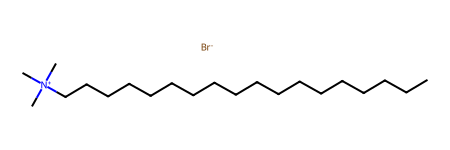

In [6]:
import rdkit
import rdkit.Chem
import rdkit.Chem.Draw
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.Draw import IPythonConsole   # hace que Jupyter dibuje los Mol

# cogemos la primera molecula del dataset
row = soldata.iloc[0]
mol = rdkit.Chem.MolFromInchi(row["InChI"])

print("nombre:     ", row["Name"])
print("SMILES:     ", row["SMILES"])
print("solubilidad:", round(row["Solubility"], 2), "log mol/L")
print("formula:    ", rdMolDescriptors.CalcMolFormula(mol))
mol

Ahí está: bromuro de trimetiloctadecilamonio, un tensioactivo catiónico. Cadena C18 larga y apolar,
cabeza amonio cuaternario cargada. Su solubilidad es −3.62.

Fíjate en que RDKit ha dibujado el `[Br-]` separado: en el SMILES, el punto (`.`) significa
"componentes desconectados". Para RDKit esto es **un solo `Mol` con dos fragmentos**, y los
descriptores (peso molecular, etc.) se calculan sobre el conjunto. Es un detalle que en datasets
con sales causa bastantes sorpresas.

### 2.3.2 ¿Cómo se reparte la solubilidad?

Un **histograma** parte el rango de valores en intervalos (*bins*) y cuenta cuántas moléculas caen en
cada uno. Sirve para ver de un vistazo dónde se concentran los datos y si hay colas raras.

Lo dibujamos con `seaborn` (una capa por encima de `matplotlib` que hace gráficas estadísticas con
una línea). El libro usa `sns.distplot`, que **ya no existe** en seaborn 0.13 — su sustituto es
`sns.histplot`.

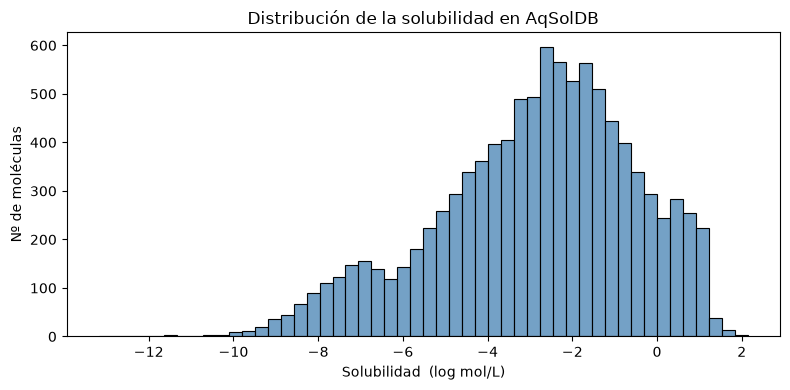

count    9982.00
mean       -2.89
std         2.37
min       -13.17
25%        -4.33
50%        -2.62
75%        -1.21
max         2.14


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(soldata["Solubility"], bins=50, ax=ax, color="steelblue")
ax.set_xlabel("Solubilidad  (log mol/L)")
ax.set_ylabel("Nº de moléculas")
ax.set_title("Distribución de la solubilidad en AqSolDB")

fig.tight_layout()
fig.savefig("../figuras/02_distribucion_solubilidad.png", dpi=150)
plt.show()

# los mismos numeros, en texto
print(soldata["Solubility"].describe().round(2).to_string())

Cómo se lee esto:

- El grueso de los datos está entre **−6 y 0**, con el pico sobre −2.5. Tiene sentido: las bases de
  datos de solubilidad se llenan de fármacos y compuestos industriales, que son moléculas de
  tamaño medio y solubilidad moderada.
- Hay una **cola larga hacia la izquierda** que llega a −13. Son los extremadamente insolubles.
  Son pocos, y eso importa: el modelo verá muy pocos ejemplos de esa zona, así que ahí predecirá mal.
- Por la derecha la cosa se corta en torno a +2. Es un límite físico, no un artefacto: por encima
  de ~100 mol/L ya no hablas de una disolución, hablas del líquido puro.
- `std` (desviación típica) ≈ 2.4. Guárdate este número: **es la vara de medir**. Un modelo que
  prediga siempre la media se equivocaría, de media, unas 2.4 unidades. Cualquier modelo que
  entrenemos tiene que bajar claramente de ahí para valer algo.

### 2.3.3 Los extremos

Ordenamos el dataset por solubilidad y miramos las 3 moléculas de cada extremo. Es la mejor
comprobación de cordura que existe: si la química de los extremos no cuadra, algo está mal en los datos.

`sort_values` devuelve una copia ordenada; `MolsToGridImage` dibuja varias moléculas en rejilla con
un pie de texto (`legends`) para cada una.

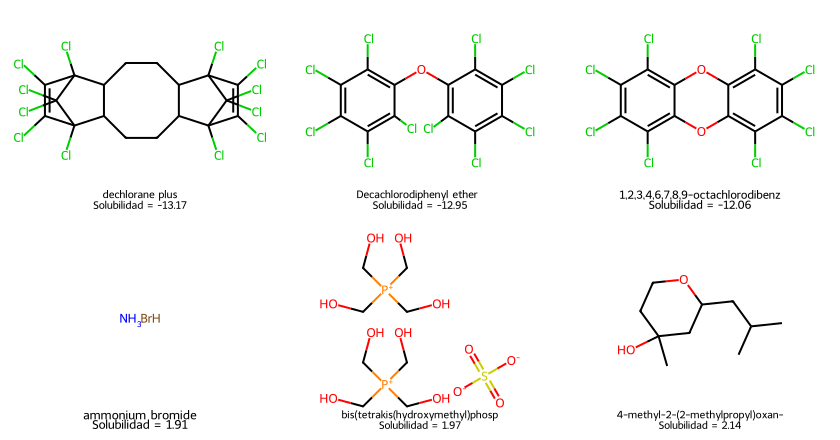

In [8]:
sorted_data = soldata.sort_values("Solubility")

extremos = pd.concat([sorted_data.head(3), sorted_data.tail(3)])

mols = [rdkit.Chem.MolFromInchi(inchi) for inchi in extremos["InChI"]]
legends = [
    f"{name[:32]}\nSolubilidad = {sol:.2f}"
    for name, sol in zip(extremos["Name"], extremos["Solubility"])
]

rdkit.Chem.Draw.MolsToGridImage(
    mols, molsPerRow=3, subImgSize=(280, 220), legends=legends
)

**Fila de arriba — los 3 más insolubles:**

| Molécula | Solubilidad | MolLogP | TPSA | Dadores H |
|---|---|---|---|---|
| dechlorane plus | −13.17 | 9.72 | 0.00 | 0 |
| decaclorodifenil éter | −12.95 | 10.01 | 9.23 | 0 |
| octaclorodibenzo-*p*-dioxina | −12.06 | 8.81 | 18.46 | 0 |

Los tres son **organoclorados policíclicos**: un retardante de llama y dos contaminantes
persistentes clásicos. El patrón salta a la vista — `MolLogP` entre 9 y 10, `TPSA` prácticamente 0,
**cero dadores de puente de hidrógeno**. Son superficies de cloro sin un solo sitio donde el agua
pueda agarrarse. Solubilidad de 10⁻¹³ mol/L: eso es del orden de una molécula por litro, y es
exactamente la razón por la que estos compuestos se bioacumulan y no se van nunca del medio ambiente.

**Fila de abajo — los 3 más solubles:**

| Molécula | Solubilidad | MolLogP | TPSA | Dadores H |
|---|---|---|---|---|
| bromuro de amonio | +1.91 | −2.62 | 36.5 | 1 |
| sulfato de bis(tetrakis(hidroximetil)fosfonio) | +1.97 | −3.73 | 242.1 | 8 |
| 4-metil-2-(2-metilpropil)oxan-4-ol | +2.14 | 1.96 | 29.5 | 1 |

Las dos primeras son **sales**: se disocian en iones y el agua las solvata sin esfuerzo. Mira los
números, son el espejo exacto de los de arriba — logP **negativo** (prefiere el agua al octanol),
TPSA alta, dadores de H de sobra.

**Pero la tercera desentona.** Un alcohol neutro con logP +1.96 y una sola TPSA de 29 no debería
ser el compuesto más soluble de las 9982 moléculas del dataset. O el dato experimental es malo, o
es un compuesto miscible con agua cuyo valor se anotó de forma distinta al resto.

Esto no es un estorbo, es la lección: **los datos experimentales reales traen ruido y errores**, y en
la cola del dataset es donde se acumulan. Un modelo entrenado con esto nunca podrá ser más preciso
que las medidas de las que aprende. Lo veremos otra vez en el capítulo 3, cuando hablemos de
cuánto error es *irreducible*.

Conclusión: los datos son coherentes en lo esencial. Podemos seguir.